In [ ]:
!pip install qkeras tensorflow scikit-learn matplotlib pandas seaborn

import qkeras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation
from qkeras import QDense, QConv2D, QActivation, quantized_bits
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Pobranie i przygotowanie danych CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Dostosowanie kształtu danych pod warstwy (CIFAR ma już kształt 32x32x3)
x_train_input = x_train
x_test_input = x_test

y_train_onehot = tf.one_hot(y_train.flatten(), 10).numpy()
y_test_onehot = tf.one_hot(y_test.flatten(), 10).numpy()
y_true = y_test.flatten()

# Etykiety klas dla CIFAR-10
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Kształt danych treningowych: {x_train_input.shape}")
print(f"Kształt danych testowych: {x_test_input.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Kształt danych treningowych: (50000, 32, 32, 3)
Kształt danych testowych: (10000, 32, 32, 3)


In [ ]:
model = Sequential([
    # Blok 1
    Conv2D(32, kernel_size=(3,3), padding='same', input_shape=(32,32,3), name='conv_0'),
    Activation('relu', name='act_0'),
    MaxPooling2D(pool_size=(2,2), name='pool_0'),

    # Blok 2
    Conv2D(64, kernel_size=(3,3), padding='same', name='conv_1'),
    Activation('relu', name='act_1'),
    MaxPooling2D(pool_size=(2,2), name='pool_1'),

    # Sekcja klasyfikacji
    Flatten(name='flatten'),
    Dense(64, name='dense_0'),
    Activation('relu', name='act_2'),
    Dense(10, name='output_dense'),
    Activation('softmax', name='softmax')
], name='cifar10_advanced_model')

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train_input, y_train_onehot, epochs=10, batch_size=128, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 187ms/step - accuracy: 0.4469 - loss: 1.5465 - val_accuracy: 0.5522 - val_loss: 1.2725
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 184ms/step - accuracy: 0.5824 - loss: 1.1889 - val_accuracy: 0.6112 - val_loss: 1.1124
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 182ms/step - accuracy: 0.6354 - loss: 1.0407 - val_accuracy: 0.6490 - val_loss: 1.0143
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.6652 - loss: 0.9561 - val_accuracy: 0.6782 - val_loss: 0.9331
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 179ms/step - accuracy: 0.6924 - loss: 0.8829 - val_accuracy: 0.6962 - val_loss: 0.8858
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.7120 - loss: 0.8258 - val_accuracy: 0.6878 - val_loss: 0.9030
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.7265 - loss: 0.7800 - val_accuracy: 0.6982 - val_loss: 0.8962
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 64s 181ms/step - accuracy: 0.7436 - loss: 0

In [ ]:
# Obliczenie wyników modelu bazowego FP32
y_pred_base_prob = model.predict(x_test_input)
y_pred_base = np.argmax(y_pred_base_prob, axis=1)

acc_base = accuracy_score(y_true, y_pred_base)
prec_base = precision_score(y_true, y_pred_base, average='macro', zero_division=0)
rec_base = recall_score(y_true, y_pred_base, average='macro', zero_division=0)
f1_base = f1_score(y_true, y_pred_base, average='macro', zero_division=0)
cm_baseline = confusion_matrix(y_true, y_pred_base)

print(f"Accuracy modelu bazowego FP32 na CIFAR-10: {acc_base:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Accuracy modelu bazowego FP32 na CIFAR-10: 0.7073


In [ ]:
def quantize_numpy(tensor, bits, int_bits):
    """
    Matematyczna emulacja formatu ap_fixed<bits, int_bits> w NumPy.
    """
    frac_bits = bits - int_bits
    delta = 2.0 ** (-frac_bits)  # Rozdzielczość (krok siatki)

    # Wyznaczenie zakresu dla kodowania U2
    min_val = - (2.0 ** (int_bits - 1))
    max_val = (2.0 ** (int_bits - 1)) - delta

    # 1. Skalowanie i zaokrąglenie do najbliższej liczby całkowitej (kwantyzacja ułamkowa)
    quantized = np.round(tensor / delta) * delta

    # 2. Saturacja (przycinanie wartości wychodzących poza zakres całkowity)
    quantized = np.clip(quantized, min_val, max_val)

    return quantized

In [ ]:
# Oryginalne konfiguracje bitowe
bit_configs = {
    '4-bit (4,1)': (4, 1),
    '6-bit (6,2)': (6, 2),
    '8-bit (8,2)': (8, 2),
    '10-bit (10,3)': (10, 3),
    '12-bit (12,4)': (12, 4)
}

# Wybieramy warstwy do przetestowania
layers_to_test = ['conv_0', 'conv_1', 'dense_0', 'output_dense']
all_results = []
saved_confusion_matrices = {}

print("Rozpoczynam badanie wpływu kwantyzacji samych wag w czystym Pythonie...\n")

for target_layer in layers_to_test:
    for config_name, (bits, int_bits) in bit_configs.items():

        # 1. Klonujemy model bazowy, aby zachować czyste wagi na kolejną iterację
        model_quant = tf.keras.models.clone_model(model)
        model_quant.set_weights(model.get_weights())

        # 2. Pobieramy wagi i biasy z badanej warstwy
        layer = model_quant.get_layer(target_layer)
        weights, biases = layer.get_weights()

        # 3. Kwantyzacja wag i biasów w NumPy
        q_weights = quantize_numpy(weights, bits, int_bits)
        q_biases = quantize_numpy(biases, bits, int_bits)

        # 4. Nadpisujemy wagi odpowiednią parą [macierz wag, wektor biasu]
        layer.set_weights([q_weights, q_biases])

        # 5. Ewaluacja modelu na zbiorze testowym
        y_pred_prob = model_quant.predict(x_test_input, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=1)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

        all_results.append({
            'Layer': target_layer,
            'Config': config_name,
            'Total Bits': bits,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

        # Zapisujemy macierz pomyłek dla konfiguracji 4-bitowej
        if bits == 4:
            saved_confusion_matrices[f"{target_layer}_izolowana"] = confusion_matrix(y_true, y_pred)

        print(f"Ukończono -> Warstwa: {target_layer:12} | Format WAG: ap_fixed<{bits},{int_bits}> | Accuracy: {acc:.4f}")

df_results = pd.DataFrame(all_results)
print("\n[SUKCES] Badanie NumPy zakończone!")

Rozpoczynam badanie wpływu kwantyzacji samych wag w czystym Pythonie...

Ukończono -> Warstwa: conv_0       | Format WAG: ap_fixed<4,1> | Accuracy: 0.4518
Ukończono -> Warstwa: conv_0       | Format WAG: ap_fixed<6,2> | Accuracy: 0.6568
Ukończono -> Warstwa: conv_0       | Format WAG: ap_fixed<8,2> | Accuracy: 0.6936
Ukończono -> Warstwa: conv_0       | Format WAG: ap_fixed<10,3> | Accuracy: 0.7036
Ukończono -> Warstwa: conv_0       | Format WAG: ap_fixed<12,4> | Accuracy: 0.7069
Ukończono -> Warstwa: conv_1       | Format WAG: ap_fixed<4,1> | Accuracy: 0.6897
Ukończono -> Warstwa: conv_1       | Format WAG: ap_fixed<6,2> | Accuracy: 0.6961
Ukończono -> Warstwa: conv_1       | Format WAG: ap_fixed<8,2> | Accuracy: 0.7072
Ukończono -> Warstwa: conv_1       | Format WAG: ap_fixed<10,3> | Accuracy: 0.7065
Ukończono -> Warstwa: conv_1       | Format WAG: ap_fixed<12,4> | Accuracy: 0.7070
Ukończono -> Warstwa: dense_0      | Format WAG: ap_fixed<4,1> | Accuracy: 0.6959
Ukończono -> Warstwa:

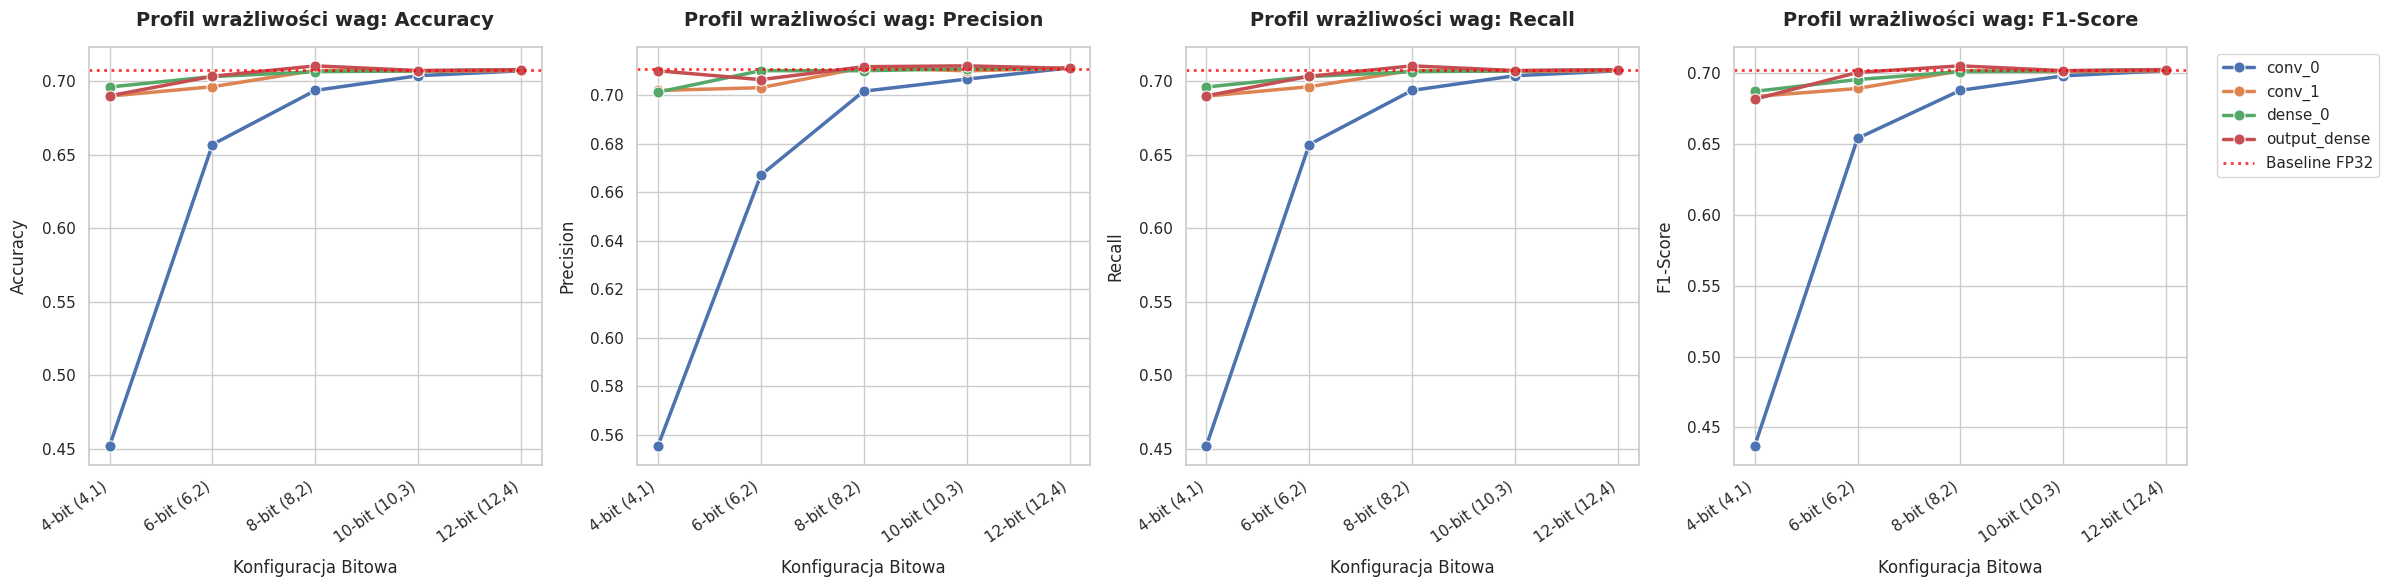

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Dodano 'Recall' do listy rysowanych metryk
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_values = {
    'Accuracy': acc_base,
    'Precision': prec_base,
    'Recall': rec_base,
    'F1-Score': f1_base
}

# Tworzymy cztery poziome subplots (zwiększony rozmiar szerokości do 24)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]

    sns.lineplot(
        data=df_results,
        x='Config',
        y=metric,
        hue='Layer',
        marker='o',
        markersize=8,
        linewidth=2.5,
        ax=ax
    )

    ax.axhline(y=baseline_values[metric], color='red', linestyle=':', linewidth=2, alpha=0.8, label='Baseline FP32')
    ax.set_title(f"Profil wrażliwości wag: {metric}", pad=15, fontweight='bold')
    ax.set_xlabel("Konfiguracja Bitowa", labelpad=10)
    ax.set_ylabel(metric, labelpad=10)
    ax.tick_params(axis='x', rotation=35)

    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')

    if idx == 3:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

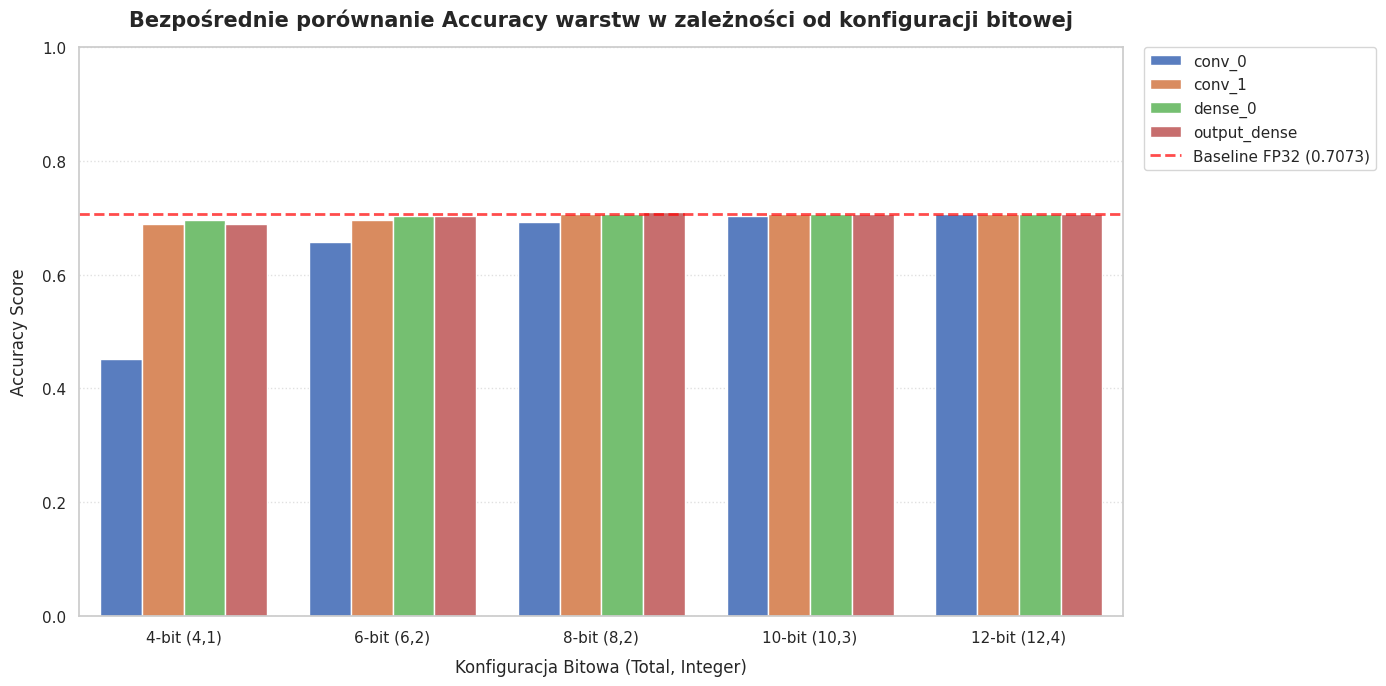

In [ ]:
plt.figure(figsize=(14, 7))

# Wykres słupkowy grupujący wyniki: na osi X konfiguracje, słupki to warstwy
sns.barplot(
    data=df_results,
    x='Config',
    y='Accuracy',
    hue='Layer',
    palette='muted'
)

# Dodanie linii bazowej modelu FP32 jako poziomego punktu odniesienia
plt.axhline(y=acc_base, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Baseline FP32 ({acc_base:.4f})')

plt.title("Bezpośrednie porównanie Accuracy warstw w zależności od konfiguracji bitowej", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Konfiguracja Bitowa (Total, Integer)", fontsize=12, labelpad=10)
plt.ylabel("Accuracy Score", fontsize=12, labelpad=10)
plt.ylim(0, 1.0) # Skala od 0 do 100% dla lepszej perspektywy spadków
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

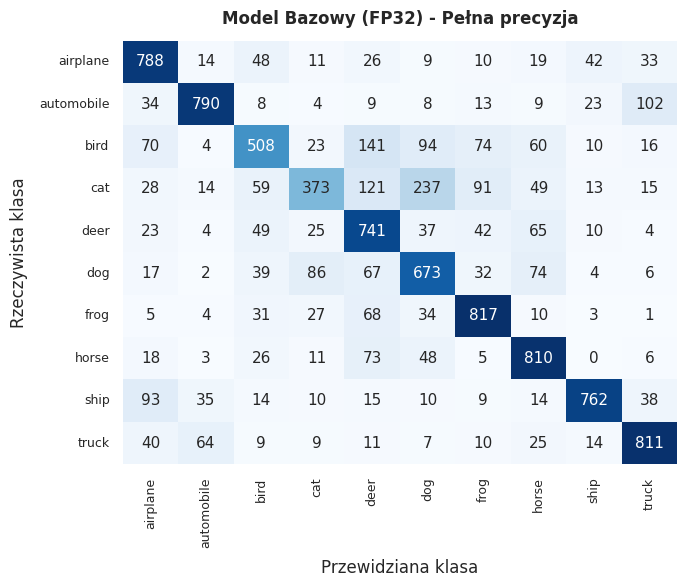

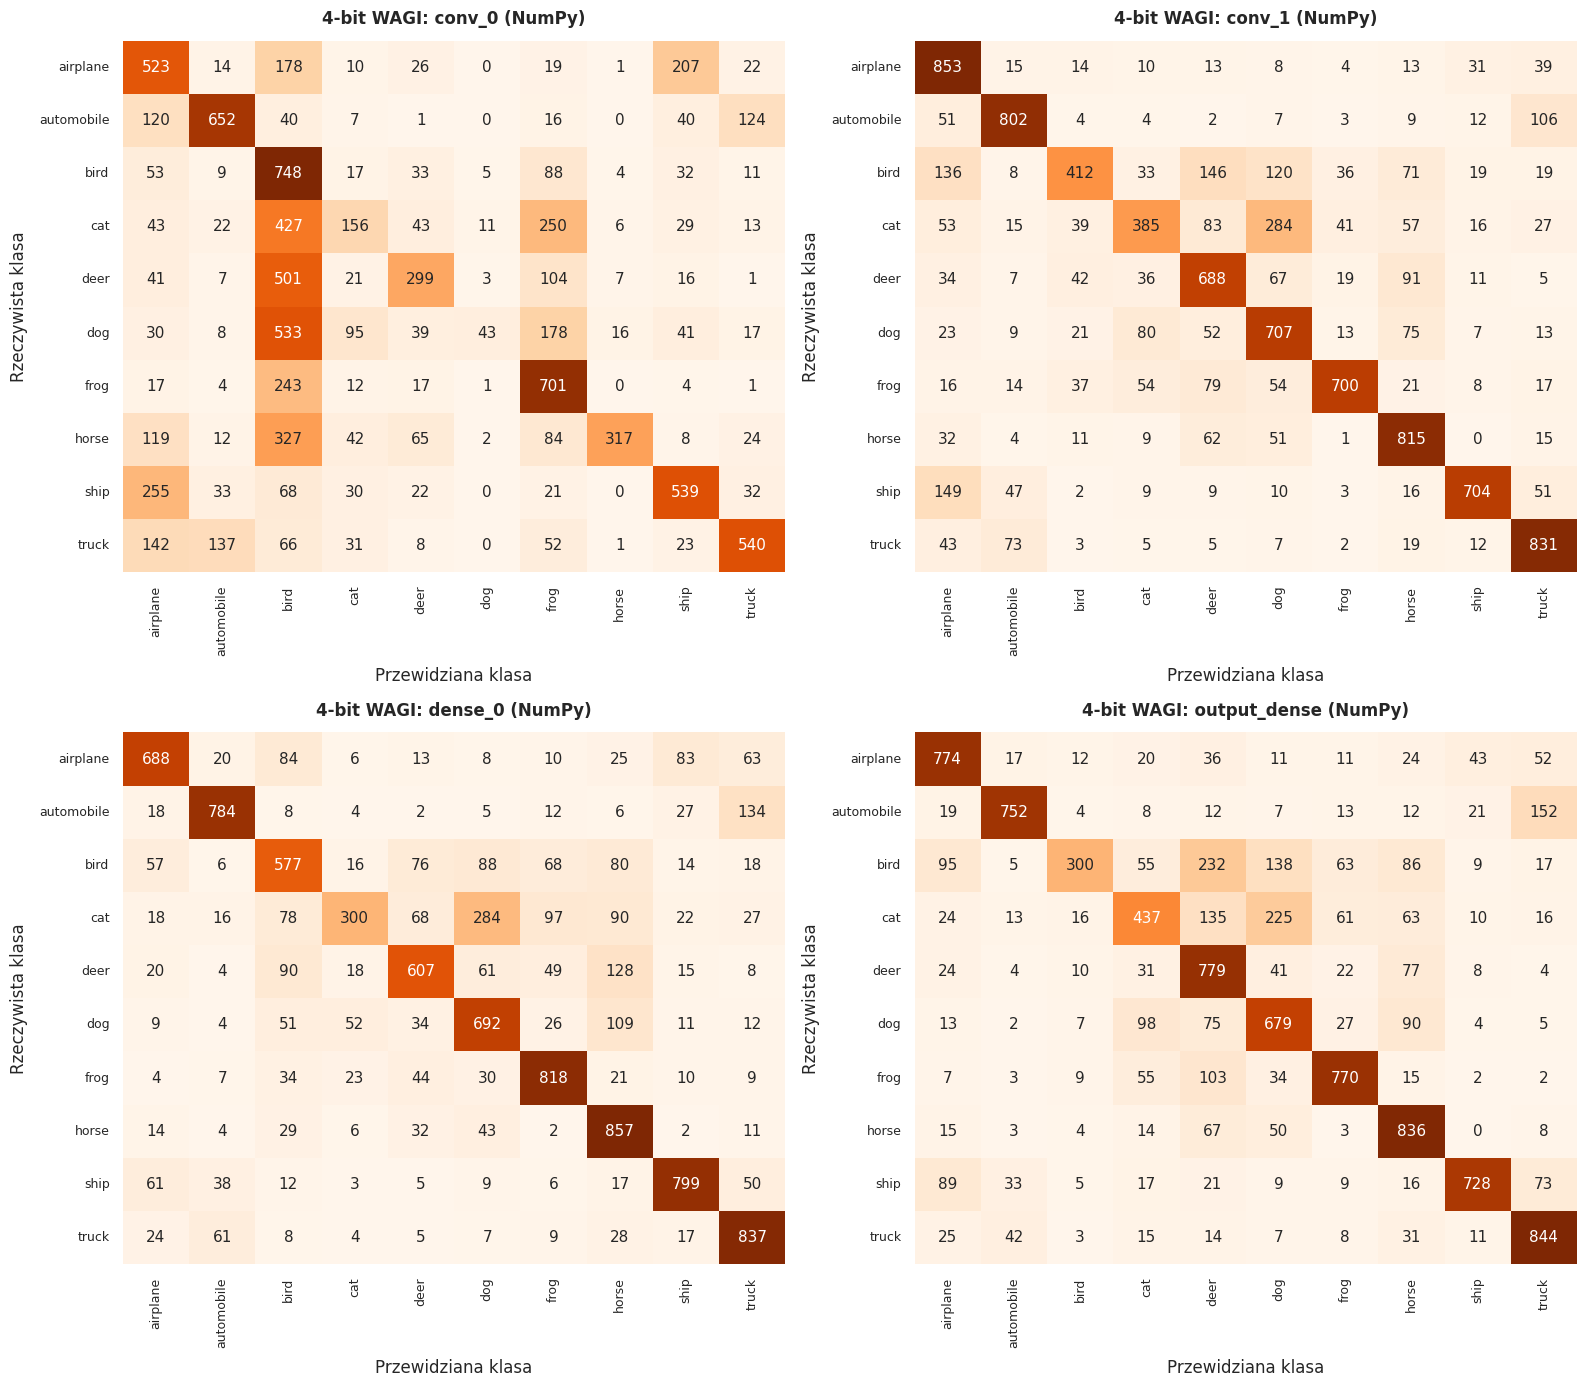

In [ ]:
# --- RYSUNEK 1: Model Bazowy FP32 ---
fig_base, ax_base = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=ax_base,
    xticklabels=cifar10_classes,
    yticklabels=cifar10_classes
)
ax_base.set_title("Model Bazowy (FP32) - Pełna precyzja", fontweight='bold', pad=12, fontsize=12)
ax_base.set_xlabel("Przewidziana klasa", labelpad=8)
ax_base.set_ylabel("Rzeczywista klasa", labelpad=8)
ax_base.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout()
plt.show()


# --- RYSUNEK 2: Wszystkie 4 skwantyzowane warstwy ---
fig_quant, axes_quant = plt.subplots(2, 2, figsize=(16, 14))
axes_flat = axes_quant.flatten()

# Lista wszystkich 4 badanych warstw w kolejności przetwarzania
order = ['conv_0', 'conv_1', 'dense_0', 'output_dense']

for idx, layer_name in enumerate(order):
    ax = axes_flat[idx]
    key = f"{layer_name}_izolowana"

    if key in saved_confusion_matrices:
        sns.heatmap(
            saved_confusion_matrices[key],
            annot=True,
            fmt='d',
            cmap='Oranges',
            cbar=False,
            ax=ax,
            xticklabels=cifar10_classes,
            yticklabels=cifar10_classes
        )
        ax.set_title(f"4-bit WAGI: {layer_name} (NumPy)", fontweight='bold', pad=12, fontsize=12)
    else:
        # Zabezpieczenie na wypadek braku danych w słowniku
        ax.text(0.5, 0.5, f"Brak danych dla:\n{layer_name}", ha='center', va='center', fontsize=12)

    ax.set_xlabel("Przewidziana klasa", labelpad=8)
    ax.set_ylabel("Rzeczywista klasa", labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout()
plt.show()